In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              roc_auc_score, roc_curve, classification_report)


In [3]:
import os, shutil

os.makedirs("data", exist_ok=True)

for fname in ["churn-bigml-80.csv", "churn-bigml-20.csv"]:
    if os.path.exists(fname):
        shutil.move(fname, f"data/{fname}")
    elif os.path.exists(f"sample_data/{fname}"):
        shutil.move(f"sample_data/{fname}", f"data/{fname}")

print(os.listdir("data"))

['churn-bigml-20.csv', 'churn-bigml-80.csv']


In [4]:
def load_and_prep(path):
    df = pd.read_csv(path)
    df["International plan"] = df["International plan"].map({"Yes": 1, "No": 0})
    df["Voice mail plan"] = df["Voice mail plan"].map({"Yes": 1, "No": 0})
    df["Churn"] = df["Churn"].astype(int)
    df = df.drop(columns=["State", "Area code"])
    return df

train_df = load_and_prep("data/churn-bigml-80.csv")
test_df = load_and_prep("data/churn-bigml-20.csv")

X_train, y_train = train_df.drop(columns=["Churn"]), train_df["Churn"]
X_test, y_test = test_df.drop(columns=["Churn"]), test_df["Churn"]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Train:", X_train.shape, "Test:", X_test.shape)


Train: (2666, 17) Test: (667, 17)


In [5]:
results = {}
for kernel in ["linear", "rbf"]:
    svm = SVC(kernel=kernel, probability=True, class_weight="balanced", random_state=42)
    svm.fit(X_train_scaled, y_train)
    y_pred = svm.predict(X_test_scaled)
    y_prob = svm.predict_proba(X_test_scaled)[:, 1]

    results[kernel] = {
        "model": svm,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "auc": roc_auc_score(y_test, y_prob),
        "y_pred": y_pred,
        "y_prob": y_prob,
    }

comparison = pd.DataFrame({k: {m: v for m, v in r.items() if m in ["accuracy","precision","recall","auc"]}
                            for k, r in results.items()}).T
comparison


,accuracy,precision,recall,auc
linear,0.770615,0.359223,0.778947,0.831837
rbf,0.902549,0.622951,0.800000,0.932269


In [6]:
print("=== Linear Kernel ===")
print(classification_report(y_test, results["linear"]["y_pred"]))
print("=== RBF Kernel ===")
print(classification_report(y_test, results["rbf"]["y_pred"]))


=== Linear Kernel ===
              precision    recall  f1-score   support

           0       0.95      0.77      0.85       572
           1       0.36      0.78      0.49        95

    accuracy                           0.77       667
   macro avg       0.66      0.77      0.67       667
weighted avg       0.87      0.77      0.80       667

=== RBF Kernel ===
              precision    recall  f1-score   support

           0       0.97      0.92      0.94       572
           1       0.62      0.80      0.70        95

    accuracy                           0.90       667
   macro avg       0.79      0.86      0.82       667
weighted avg       0.92      0.90      0.91       667



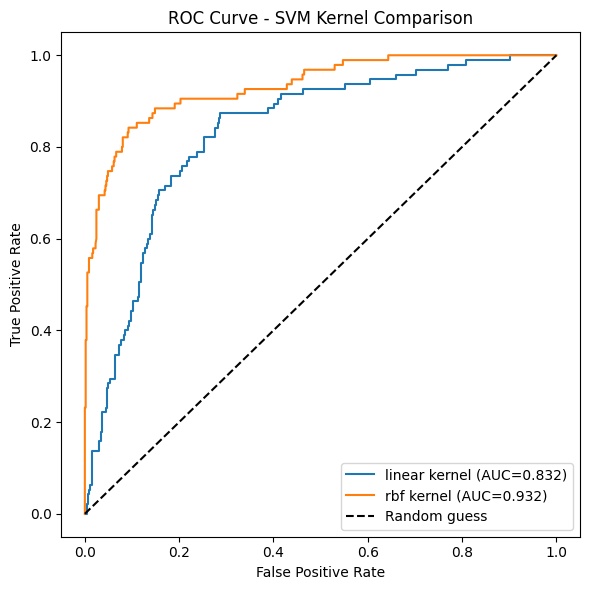

In [7]:
fig, ax = plt.subplots(figsize=(6, 6))
for kernel in ["linear", "rbf"]:
    fpr, tpr, _ = roc_curve(y_test, results[kernel]["y_prob"])
    ax.plot(fpr, tpr, label=f"{kernel} kernel (AUC={results[kernel]['auc']:.3f})")
ax.plot([0, 1], [0, 1], "k--", label="Random guess")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve - SVM Kernel Comparison")
ax.legend()
plt.tight_layout()
plt.show()


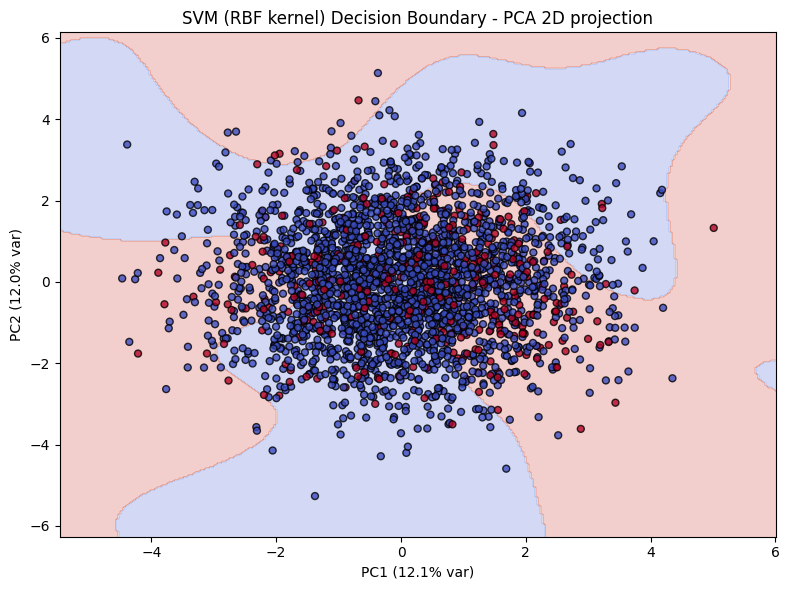

In [8]:
pca = PCA(n_components=2)
X_train_2d = pca.fit_transform(X_train_scaled)

svm_2d = SVC(kernel="rbf", class_weight="balanced", random_state=42)
svm_2d.fit(X_train_2d, y_train)

x_min, x_max = X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1
y_min, y_max = X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
Z = svm_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(8, 6))
ax.contourf(xx, yy, Z, alpha=0.25, cmap="coolwarm")
scatter = ax.scatter(X_train_2d[:, 0], X_train_2d[:, 1], c=y_train, cmap="coolwarm",
                      edgecolor="k", s=25, alpha=0.8)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
ax.set_title("SVM (RBF kernel) Decision Boundary - PCA 2D projection")
plt.tight_layout()
plt.show()
